# ANN for Power Plant Energy Output Prediction

PyTorch feedforward network predicting energy output (PE) from temperature,
vacuum, pressure, and humidity. Initially used a Sigmoid output activation,
which is wrong for regression — it capped predictions between 0-1 while the
target ranges ~440-480, so the loss stayed flat and the model never learned.
Fixed by removing it, and corrected a scaler leakage bug where the test set
was being re-fit instead of transformed. Final R² ≈ 0.93.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("powerplant_data.csv")

In [3]:
df.head()
# AT-> Temperature
# v-> Vaccum
# AP-> Pressure
# RH-> Humidity

#PE-> produced Energy(target feature)

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.dtypes
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [5]:
x=df.drop(columns=["PE"])
y=df["PE"]
x.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [8]:
import torch
import torch.nn as nn

x_train_tensor=torch.tensor(x_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)
x_test_tensor=torch.tensor(x_test_scaled,dtype=torch.float32)

In [9]:
type(y_train)

pandas.core.series.Series

In [10]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset=TensorDataset(x_train_tensor,y_train_tensor)
test_dataset=TensorDataset(x_test_tensor,y_test_tensor)


In [11]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [12]:
#building ANN architecture

In [13]:
class ANN(nn.Module): # nnModule is a base class
  def __init__(self):
    super(ANN, self).__init__()

    self.model=nn.Sequential(
        nn.Linear(x_train.shape[1],6), #creating first hidden layer
        nn.ReLU(),

        nn.Linear(6,6), #creating second hiddenlayer
        nn.ReLU(),

        nn.Linear(6,1),

  )

  def forward(self,x):
    return self.model(x)


In [14]:
import torch.optim as optim
model=ANN()

criteria=nn.MSELoss()
optimizer=optim.Adam(model.parameters())


In [15]:
# train the model

testing_loss=[]
training_loss=[]
epochs=50
best_val_model=float('inf')

for epoch in range(epochs):
  model.train()
  running_loss=0.0
  running_test_loss=0.0

  for xb,yb in train_loader:
    #xb features of one batch.
    #yb labels of 1 batch

    optimizer.zero_grad() # always compute fresh gradient on each iteraion.

    output=model(xb) # forward propogation compute output
    loss=criteria(output,yb) #compute loss
    loss.backward() # back propogation compute gradient(slope-> dL/dw).

    optimizer.step() #parameter update

    running_loss+=loss.item() #loss is a tensor converting into float using item


  epoch_train_loss=running_loss/len(train_loader)
  training_loss.append(epoch_train_loss)

  # validation/evaluation
  model.eval()
  with torch.no_grad():
    for xb,yb in test_loader:
      output=model(xb)
      loss=criteria(output,yb)
      running_test_loss+=loss.item()

  epoch_val_loss=running_test_loss/len(test_loader)
  testing_loss.append(epoch_val_loss)


  print(f"Epoch {epoch+1}/{epochs}, Training Loss: {epoch_train_loss:.4f}")

  if loss<best_val_model:
      best_val_model=loss
      torch.save(model.state_dict(),"best_model.pth")


Epoch 1/50, Training Loss: 206140.4001
Epoch 2/50, Training Loss: 199944.9023
Epoch 3/50, Training Loss: 173919.8773
Epoch 4/50, Training Loss: 121490.8635
Epoch 5/50, Training Loss: 65161.9692
Epoch 6/50, Training Loss: 32045.2468
Epoch 7/50, Training Loss: 18850.7307
Epoch 8/50, Training Loss: 14004.0372
Epoch 9/50, Training Loss: 10926.8071
Epoch 10/50, Training Loss: 8400.1882
Epoch 11/50, Training Loss: 6176.6592
Epoch 12/50, Training Loss: 4326.7854
Epoch 13/50, Training Loss: 2941.3722
Epoch 14/50, Training Loss: 1991.5028
Epoch 15/50, Training Loss: 1352.7274
Epoch 16/50, Training Loss: 929.1746
Epoch 17/50, Training Loss: 658.9584
Epoch 18/50, Training Loss: 485.9621
Epoch 19/50, Training Loss: 362.3189
Epoch 20/50, Training Loss: 275.2817
Epoch 21/50, Training Loss: 210.9973
Epoch 22/50, Training Loss: 161.6433
Epoch 23/50, Training Loss: 124.0491
Epoch 24/50, Training Loss: 96.1884
Epoch 25/50, Training Loss: 75.5138
Epoch 26/50, Training Loss: 60.3131
Epoch 27/50, Training 

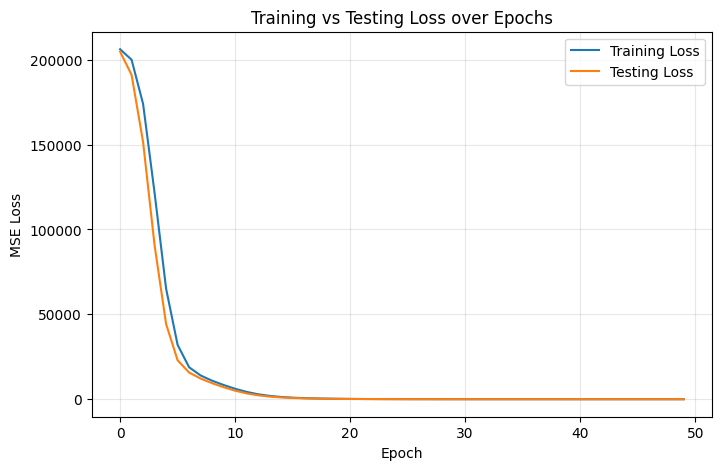

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(training_loss, label="Training Loss")
plt.plot(testing_loss, label="Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Testing Loss over Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [18]:
model.eval()

with torch.no_grad():
  train_preds=model(x_train_tensor)
  test_preds=model(x_test_tensor)

  train_mse=criteria(train_preds,y_train_tensor)
  test_mse=criteria(test_preds,y_test_tensor)


print(f"Training MSE: {train_mse.item()}")
print(f"Testing MSE: {test_mse.item()}")


Training MSE: 21.30318260192871
Testing MSE: 19.976333618164062


In [19]:
from sklearn.metrics import r2_score

print(f"r2 score is : {r2_score(y_test,test_preds)}")

r2 score is : 0.9301878702246296
